In [14]:
%reset -f

In [15]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

In [16]:
### READ DATA
device_name = "A1-RBX-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

In [17]:
# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

In [18]:
def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)
df_numeric_names = get_column_names_exclude(df, "cpu", "unused") +\
                    get_column_names_exclude(df, "temperature", "status") +\
                    get_column_names_exclude(df, "ICMP", "loss")

In [19]:
df_bits = df.get_column_values(df_columns_bits_names)
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')

df_numeric = df.get_column_values(df_numeric_names)
df_numeric.columns = df_numeric.columns.str.replace('HotSpot Temp Sensor:', '')
df_numeric.columns = df_numeric.columns.str.replace('Inlet Temp Sensor:', '1')
df_numeric.columns = df_numeric.columns.str.replace('Outlet Temp Sensor:', '2')

In [20]:
# remove nans
df_bits = remove_outliers(df_bits, 1).dropna()
df_numeric = remove_outliers(df_numeric, 1).dropna()

In [21]:
# create dictionary for pairs of values ratio of in/out traffic
traffic_pairs = {}
for col in df_bits.columns:
    if col.endswith('in'):
        out_col = col[:-2] + 'out'
        if out_col in df_bits.columns:
            traffic_pairs[col] = out_col


In [22]:
# calculate ratios of in/out traffic for each port
import pandas as pd

df_ratios = pd.DataFrame(index=df_bits.index)

for in_col, out_col in traffic_pairs.items():
    # get port name by removing 'in' suffix
    port_name = in_col[:-2] if in_col.endswith('in') else in_col
    
    # calculate ratio (in/out), handle division by zero
    ratio_col = f"{port_name}_ratio"
    df_ratios[ratio_col] = df_bits[in_col] / df_bits[out_col].replace(0, 1e-10)  # Avoid division by zero

print(f"Original df_bits shape: {df_bits.shape}")
print(f"New df_ratios shape: {df_ratios.shape}")
print(f"Ratio columns: {list(df_ratios.columns)}")

Original df_bits shape: (39432, 6)
New df_ratios shape: (39432, 3)
Ratio columns: ['1/1( FIREWALL connection): _ratio', '1/3(Valmet PRP LAN_A-connection): _ratio', '1/4(Valmet PRP LAN_B-connection): _ratio']


In [23]:
# remove zeros from ratios

for col in df_ratios.columns:
    if df_ratios[col].sum() == 0:
        df_ratios.drop(col, axis=1, inplace=True)

In [24]:
df_port_rations_and_other_numerics = pd.concat([df_ratios, df_numeric], axis=1)

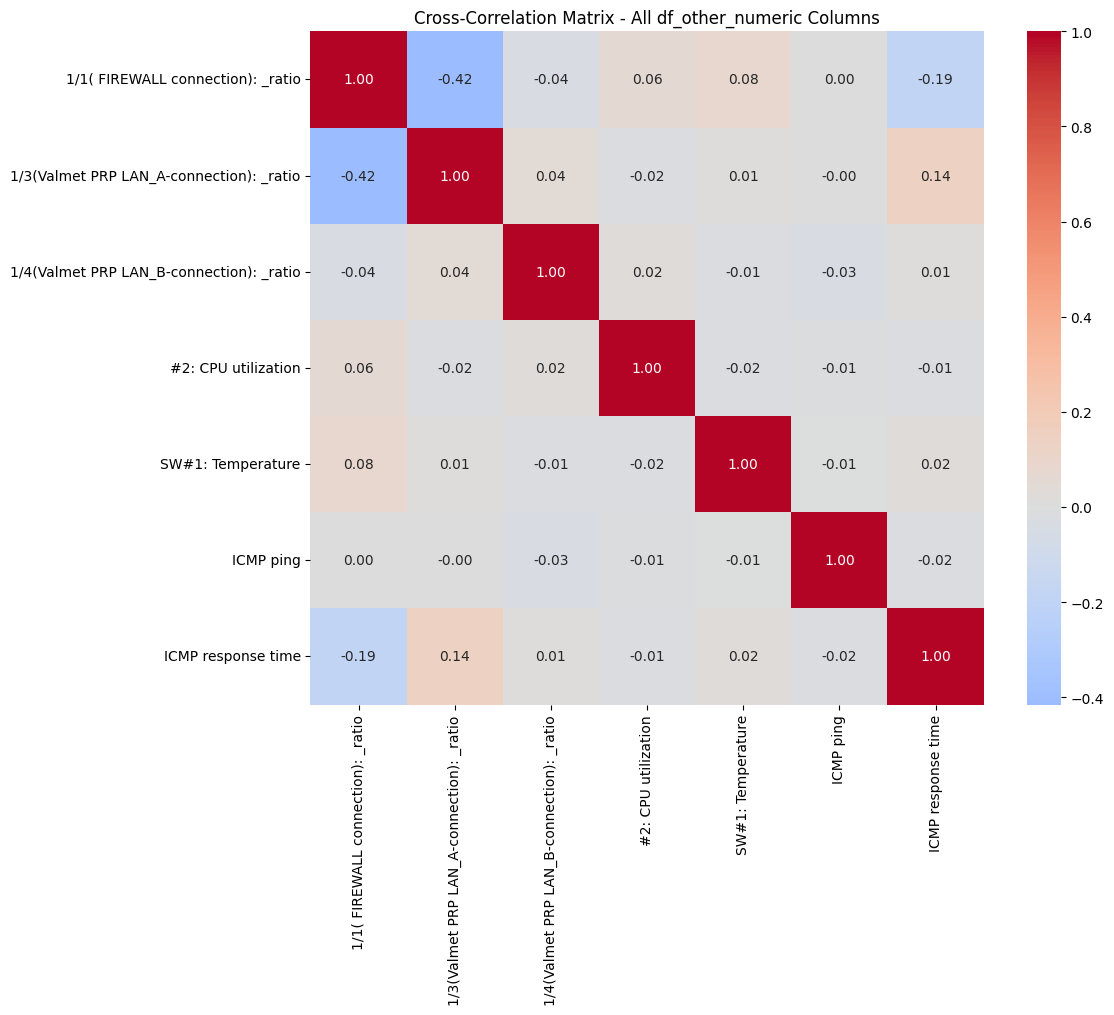

In [25]:
# cross-correlation between ratios of values on each pair on ports and other numeric values

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# calculate correlation matrix
correlation_matrix = df_port_rations_and_other_numerics.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Cross-Correlation Matrix - All df_other_numeric Columns')
plt.tight_layout()
plt.show()

moderate correlation between cpu and ratio of traffic on ports, indicates that this parameter can support forecasting of described values. In next step, the forecasted ratios should be compared and if one or more is significantly higher, it means there is storm.
